# **MÓDULO 40 - Exercicio - Aplicando SVM**

Nessa atividade vocês usarão uma base já connhecida, a base de propensão a compra de carros. A mesma que também usamos na tarefa de XGboost!


In [1]:
from sklearn.svm import SVC
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 1. Carrega a base de dados, verifique os tipos de dados, dados faltantes e drop a coluna ID.


In [2]:
# Carregando a base
base = pd.read_csv('CARRO_CLIENTES.csv')

# Visualizando as primeiras linhas
base.head()

,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0


In [3]:
# Verificando o tamanho da base
base.shape

(1000, 5)

In [4]:
# Verificando os tipos de dados
base.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   User ID       1000 non-null   int64
 1   Gender        1000 non-null   str  
 2   Age           1000 non-null   int64
 3   AnnualSalary  1000 non-null   int64
 4   Purchased     1000 non-null   int64
dtypes: int64(4), str(1)
memory usage: 39.2 KB


In [5]:
;# Verificando dados nulos
base.isnull().sum()

User ID         0
Gender          0
Age             0
AnnualSalary    0
Purchased       0
dtype: int64

In [6]:
# Removendo a coluna ID
base = base.drop(columns=['User ID'])

# Conferindo a base após remover o ID
base.head()

,Gender,Age,AnnualSalary,Purchased
0,Male,35,20000,0
1,Male,40,43500,0
2,Male,49,74000,0
3,Male,40,107500,1
4,Male,25,79000,0


In [7]:
# Verificando dados estatísticos
base.describe()

,Age,AnnualSalary,Purchased
count,1000.000000,1000.000000,1000.000000
mean,40.106000,72689.000000,0.402000
std,10.707073,34488.341867,0.490547
min,18.000000,15000.000000,0.000000
25%,32.000000,46375.000000,0.000000
50%,40.000000,72000.000000,0.000000
75%,48.000000,90000.000000,1.000000
max,63.000000,152500.000000,1.000000


A base possui 1000 registros e, inicialmente, 5 colunas. A coluna User ID foi removida por ser apenas um identificador, sem contribuição relevante para a previsão. Também foi verificado que a base não possui dados faltantes.

# 2. Aplique o Label Encoder para a coluna Gender e exclua a coluna categórica.

In [8]:
# Aplicando Label Encoder na variável categórica Gender
label_encoder = LabelEncoder()

base['Gender_encoded'] = label_encoder.fit_transform(base['Gender'])

# Removendo a coluna categórica original
base = base.drop(columns=['Gender'])

# Visualizando a base transformada
base.head()

,Age,AnnualSalary,Purchased,Gender_encoded
0,35,20000,0,1
1,40,43500,0,1
2,49,74000,0,1
3,40,107500,1,1
4,25,79000,0,1


In [9]:
# Verificando como as classes foram codificadas
for classe, codigo in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f'{classe}: {codigo}')

Female: 0
Male: 1


A variável categórica Gender foi transformada em variável numérica com Label Encoder. Após a codificação, a coluna original foi removida, mantendo apenas a versão numérica Gender_encoded.

# 3. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

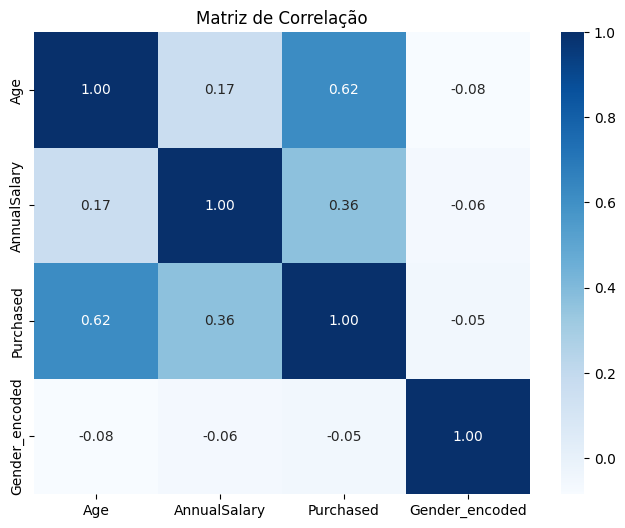

In [10]:
# Calculando a matriz de correlação
correlacao = base.corr()

# Plotando a matriz de correlação
plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, cmap='Blues', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

In [11]:
# Correlação das variáveis com a variável target
correlacao_target = correlacao['Purchased'].sort_values(ascending=False)

correlacao_target

Purchased         1.000000
Age               0.616036
AnnualSalary      0.364974
Gender_encoded   -0.047211
Name: Purchased, dtype: float64

A variável Age apresenta a maior correlação positiva com a variável target Purchased, indicando que a idade possui forte relação com a decisão de compra. A variável AnnualSalary também apresenta correlação positiva, porém menor. Já Gender_encoded possui baixa correlação com a variável alvo, sugerindo pouca influência direta na intenção de compra.

# 4. Faça a separação da base em X e Y e em seguida nas bases de treino e teste.

In [12]:
# Separando a variável dependente Y e as variáveis independentes X
X = base.drop(columns=['Purchased'])
Y = base['Purchased']

In [13]:
# Separando em base de treino e teste
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('Y_train:', Y_train.shape)
print('Y_test:', Y_test.shape)

X_train: (800, 3)
X_test: (200, 3)
Y_train: (800,)
Y_test: (200,)


A variável Purchased foi definida como variável dependente, pois representa se o cliente comprou ou não. As demais variáveis foram usadas como explicativas. A base foi separada em treino e teste, mantendo a proporção das classes com stratify.

**Todos passos até aqui vocês realizaram na tarefa anterior também!**

In [14]:
# Padronizando os dados para o SVM
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Foi aplicada a padronização dos dados antes do treinamento dos modelos SVM, pois esse tipo de algoritmo é sensível à escala das variáveis. Como a variável AnnualSalary possui valores muito maiores que as demais, a padronização ajuda o modelo a treinar de forma mais adequada e eficiente.

# 5. Treino o modelo SVM com sua base de treino.
Esse modelo deve ser treinado usando o kernel linear.

In [15]:
# Criando o modelo SVM com kernel linear
svm_model_linear = SVC(kernel='linear', random_state=1, C=1.0)

# Treinando o modelo com os dados padronizados
svm_model_linear.fit(X_train_scaled, Y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


O modelo SVM foi treinado utilizando o kernel linear, conforme apresentado na aula. Esse tipo de kernel busca separar as classes por meio de uma fronteira linear, sendo indicado quando os dados apresentam uma separação mais simples entre as classes.

# 6. Realize as previsões para a base de teste e traga a avaliação.

In [16]:
# Realizando previsões com a base de teste padronizada
Y_pred_linear = svm_model_linear.predict(X_test_scaled)

Y_pred_linear

array([0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0])

In [17]:
# Relatório de classificação
report_linear = classification_report(Y_test, Y_pred_linear)

print('Relatório de Classificação - SVM Linear:\n')
print(report_linear)

Relatório de Classificação - SVM Linear:

              precision    recall  f1-score   support

           0       0.85      0.92      0.88       120
           1       0.86      0.76      0.81        80

    accuracy                           0.85       200
   macro avg       0.86      0.84      0.85       200
weighted avg       0.86      0.85      0.85       200



In [18]:
# Calculando a acurácia
accuracy_linear = accuracy_score(Y_test, Y_pred_linear)

print('Acurácia SVM Linear:', accuracy_linear)

Acurácia SVM Linear: 0.855


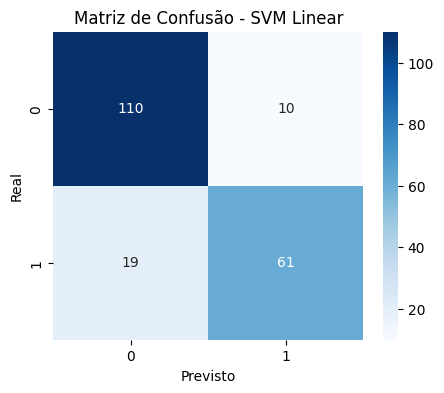

In [19]:
# Matriz de confusão
matriz_linear = confusion_matrix(Y_test, Y_pred_linear)

plt.figure(figsize=(5, 4))
sns.heatmap(matriz_linear, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - SVM Linear')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

O modelo SVM com kernel linear foi avaliado utilizando a base de teste. A avaliação foi feita por meio da acurácia, do relatório de classificação e da matriz de confusão. Essas métricas permitem analisar o desempenho geral do modelo e verificar a quantidade de acertos e erros nas previsões.

# 7. Treine um novo modelo SVM com sua base de treino + realize as previsões e avalições.
Esse modelo dedve ser treinado usando o kernel poly.

In [20]:
# Criando o modelo SVM com kernel polinomial
svm_model_poly = SVC(kernel='poly', degree=2, random_state=1, C=1.0)

# Treinando o modelo com os dados padronizados
svm_model_poly.fit(X_train_scaled, Y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",2
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [21]:
# Realizando previsões com a base de teste padronizada
Y_pred_poly = svm_model_poly.predict(X_test_scaled)

Y_pred_poly

array([0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0])

In [22]:
# Relatório de classificação
report_poly = classification_report(Y_test, Y_pred_poly)

print('Relatório de Classificação - SVM Poly:\n')
print(report_poly)

Relatório de Classificação - SVM Poly:

              precision    recall  f1-score   support

           0       0.72      0.89      0.80       120
           1       0.75      0.49      0.59        80

    accuracy                           0.73       200
   macro avg       0.74      0.69      0.69       200
weighted avg       0.73      0.73      0.72       200



In [23]:
# Calculando a acurácia
accuracy_poly = accuracy_score(Y_test, Y_pred_poly)

print('Acurácia SVM Poly:', accuracy_poly)

Acurácia SVM Poly: 0.73


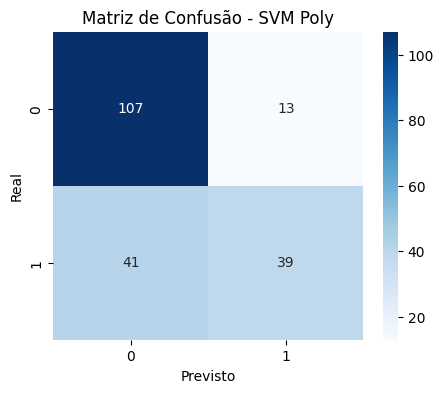

In [24]:
# Matriz de confusão
matriz_poly = confusion_matrix(Y_test, Y_pred_poly)

plt.figure(figsize=(5, 4))
sns.heatmap(matriz_poly, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - SVM Poly')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

O segundo modelo SVM foi treinado utilizando o kernel polinomial, também apresentado na aula. Esse kernel permite representar relações mais complexas entre as variáveis, podendo ser útil quando a separação entre as classes não ocorre de forma totalmente linear.

# 8. Qual modelo se saiu melhor? O SVM com kernel linear ou poly? Compare também com o XGboost, da atividade anterior, você obteve melhores previsões com qual dos modelos?

In [25]:
# Acurácia obtida na atividade anterior com XGBoost
accuracy_xgboost = 0.905

In [26]:
# Criando tabela comparativa dos modelos
resultados = pd.DataFrame({
    'Modelo': ['SVM Linear', 'SVM Poly', 'XGBoost'],
    'Acurácia': [accuracy_linear, accuracy_poly, accuracy_xgboost]
})

resultados

,Modelo,Acurácia
0,SVM Linear,0.855
1,SVM Poly,0.730
2,XGBoost,0.905


In [27]:
# Ordenando os modelos pela acurácia
resultados_ordenados = resultados.sort_values(by='Acurácia', ascending=False)

resultados_ordenados

,Modelo,Acurácia
2,XGBoost,0.905
0,SVM Linear,0.855
1,SVM Poly,0.730


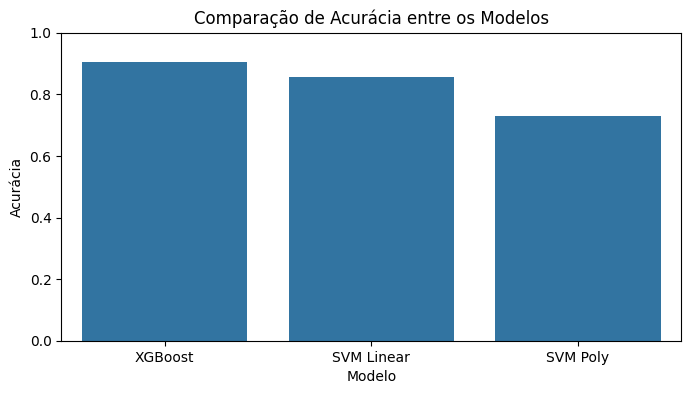

In [28]:
# Gráfico comparativo
plt.figure(figsize=(8, 4))
sns.barplot(data=resultados_ordenados, x='Modelo', y='Acurácia')
plt.title('Comparação de Acurácia entre os Modelos')
plt.ylim(0, 1)
plt.show()

In [29]:
# Identificando o melhor modelo
melhor_modelo = resultados_ordenados.iloc[0]

print('Melhor modelo:', melhor_modelo['Modelo'])
print('Acurácia:', melhor_modelo['Acurácia'])

Melhor modelo: XGBoost
Acurácia: 0.905


Ao comparar os modelos, o XGBoost apresentou o melhor desempenho, com acurácia de 0.905. Em seguida, o SVM com kernel linear obteve acurácia de 0.855, enquanto o SVM com kernel polinomial apresentou acurácia de 0.730. Dessa forma, para esta base de dados, o XGBoost foi o modelo que obteve as melhores previsões. O SVM Linear também apresentou um bom desempenho, enquanto o SVM Poly teve maior dificuldade em classificar corretamente os clientes que compraram.